In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Male baboons GC and T3 Anonymized.csv")
## Cleaning the dataset


# Removing completely empty rows or columns
df = df.dropna(how='all')          # drop rows that are fully empty
df = df.dropna(axis=1, how='all')  # drop columns that are fully empty

# Remove unnamed index-like columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,Male_ID,Group_ID,Collection_date,Hydroyear,T3_conc,GC_conc,Season,Rainfall,Tav,Group_size,Hierarchy_stability,T3_storage,GC_storage,Age,Alpha_status,Ordinal_rank,Consortships,Aggression,Genetic_ancestry
0,110,F,11/4/2004,2005,66.73,29.06,short rain,8.0,24.0,6,stable,16.73,0.78,12.11,non-alpha,6,0.0,-0.27,0.240
1,19,F,11/4/2004,2005,104.48,38.89,short rain,8.0,24.0,6,stable,16.73,0.78,8.23,non-alpha,3,34.0,-0.27,0.531
2,172,D,11/5/2004,2005,133.03,64.19,short rain,8.0,24.1,8,unstable,16.74,0.77,7.88,alpha,1,0.0,-0.33,0.517
3,116,D,11/5/2004,2005,77.25,27.78,short rain,8.0,24.1,8,unstable,16.72,0.77,7.95,non-alpha,2,0.0,-0.03,0.617
4,63,D,11/5/2004,2005,109.12,74.61,short rain,8.0,24.1,8,unstable,16.74,0.77,6.80,non-alpha,6,0.0,0.15,0.795


In [2]:
#exporting the cleaned dataset

df.to_csv("cleaned_baboon_data.csv", index=False)

In [3]:
##Summary statistics

numeric = df.select_dtypes(include=[np.number])
summary_stats = pd.DataFrame({
    "mean": numeric.mean(),
    "median": numeric.median(),
    "std": numeric.std(),
    "min": numeric.min(),
    "max": numeric.max(),
    "range": numeric.max() - numeric.min()
})

summary_stats

,mean,median,std,min,max,range
Male_ID,110.390888,113.00,54.807939,1.000,204.000,203.000
Hydroyear,2011.252714,2011.00,3.671307,2005.000,2018.000,13.000
T3_conc,119.588369,110.12,57.612649,17.840,1557.820,1539.980
GC_conc,79.939791,71.83,41.104079,13.110,471.360,458.250
Rainfall,25.180115,8.00,37.513546,0.000,278.000,278.000
Tav,23.502044,23.90,1.497674,19.800,26.500,6.700
Group_size,10.675112,10.00,3.910526,3.000,21.000,18.000
T3_storage,9.021776,9.44,4.078967,0.860,16.740,15.880
GC_storage,0.959001,0.87,0.406278,0.240,2.280,2.040
Age,12.290573,11.67,3.212922,6.800,25.120,18.320


## Histograms and Boxplots for ALL numeric variables

Matplotlib is building the font cache; this may take a moment.


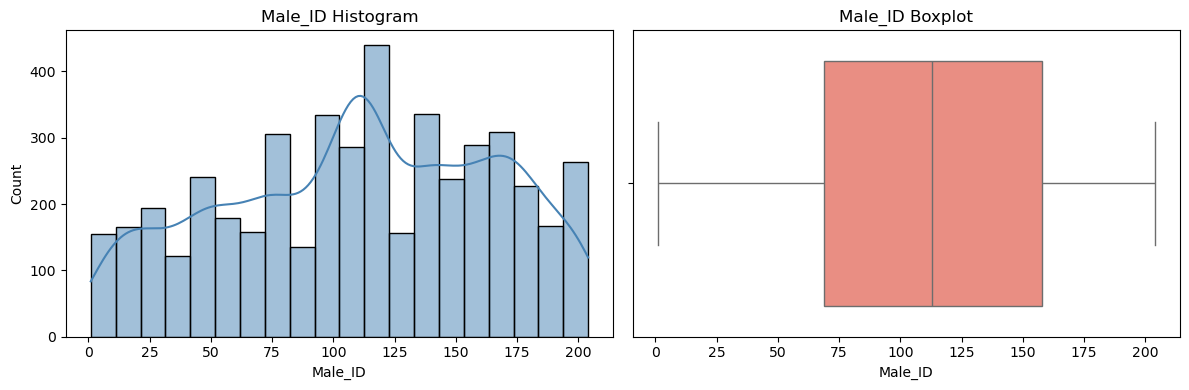

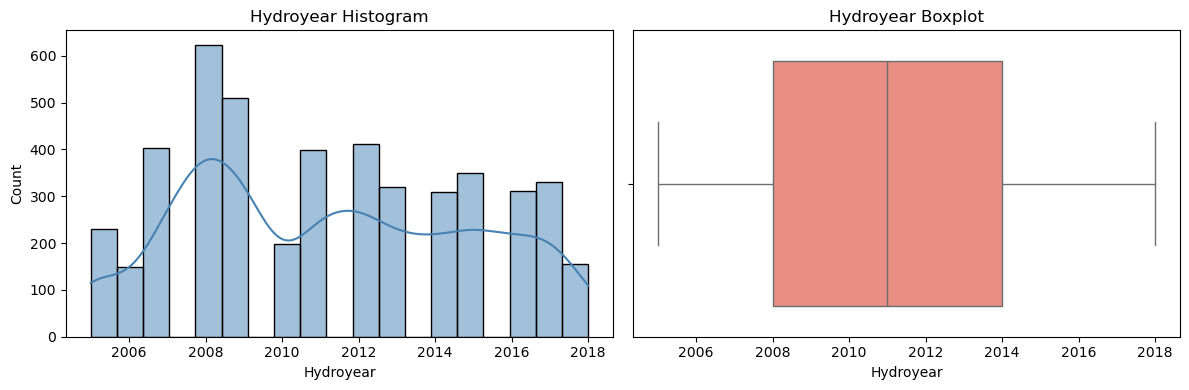

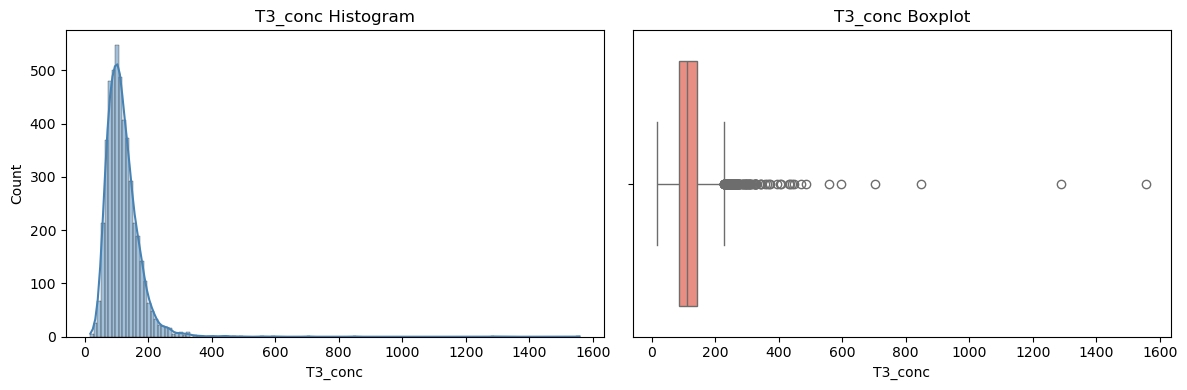

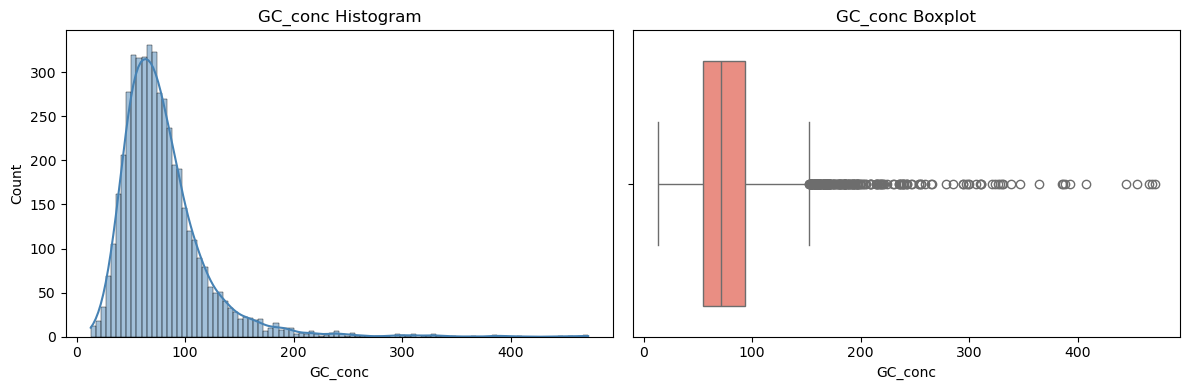

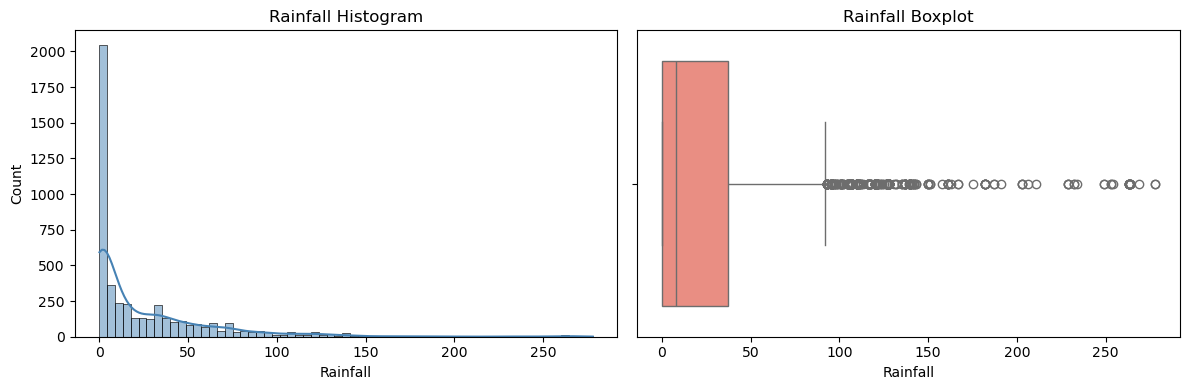

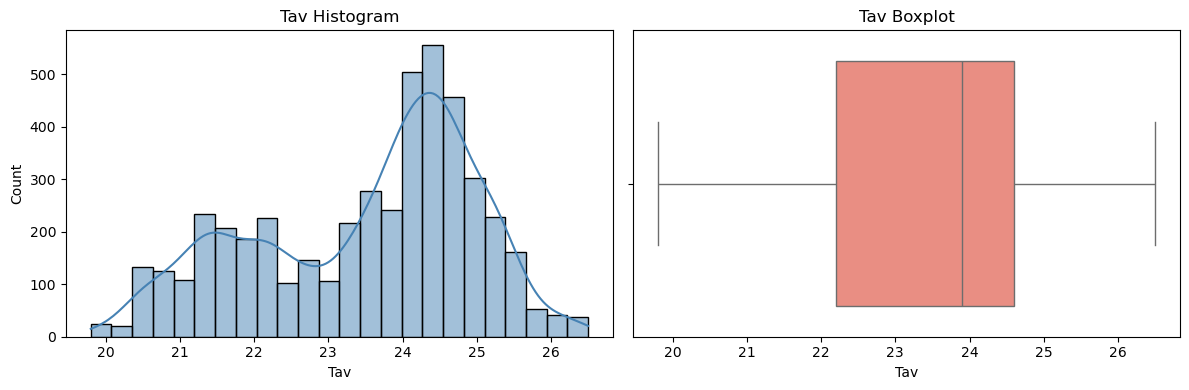

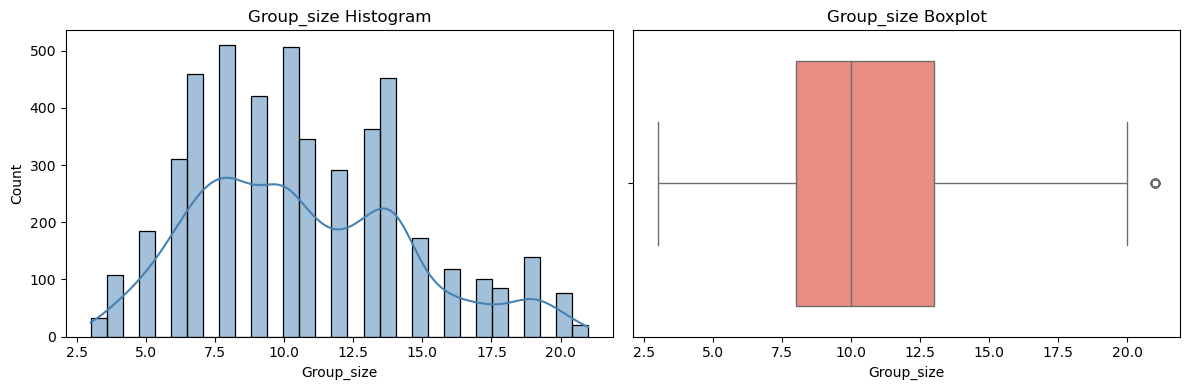

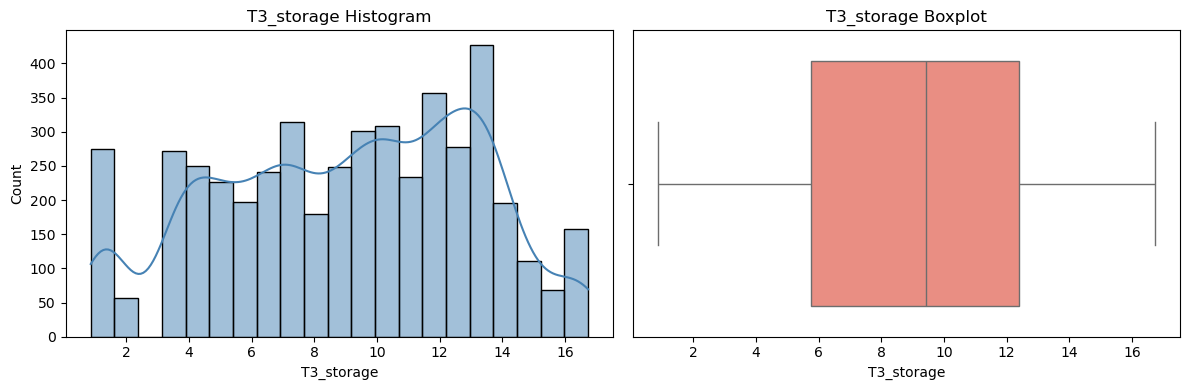

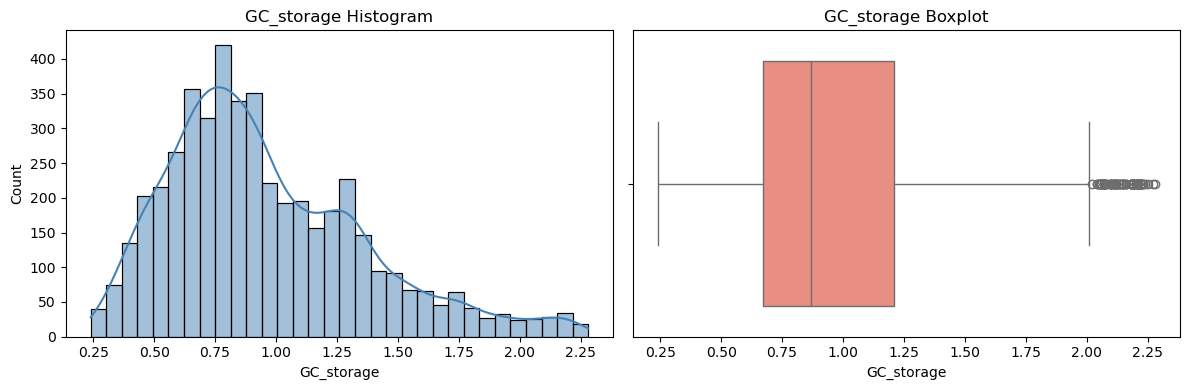

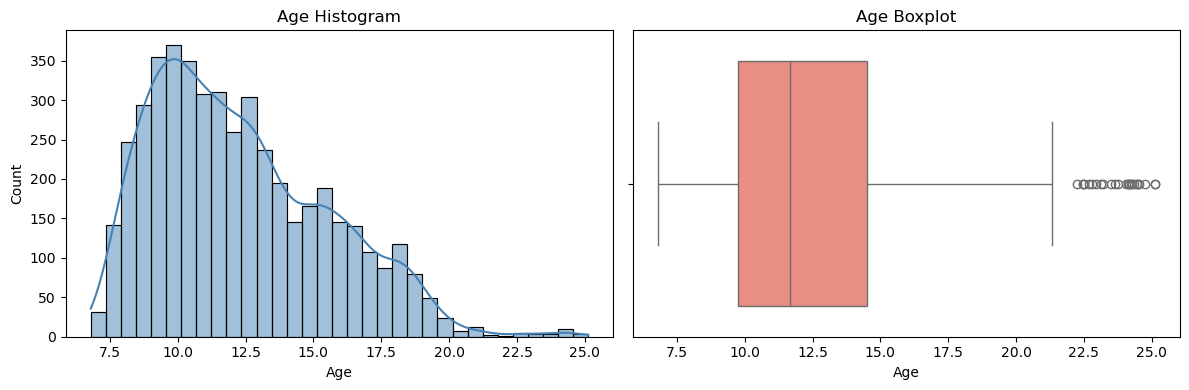

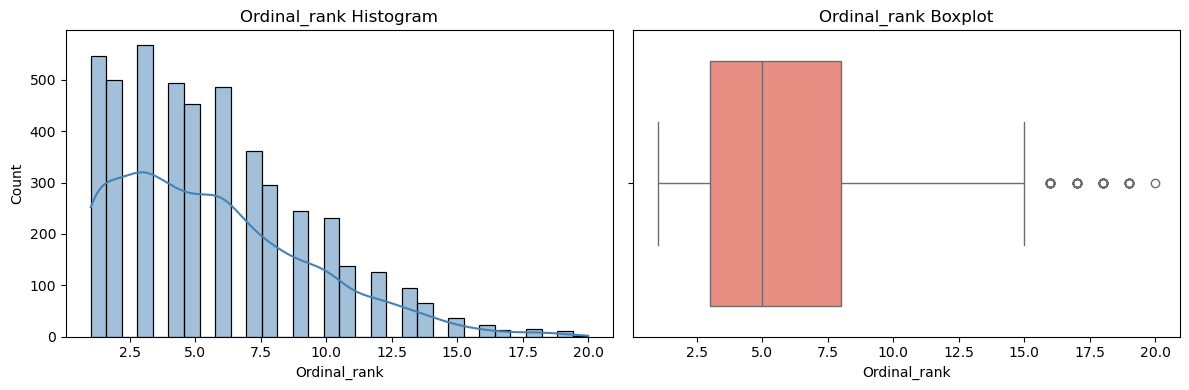

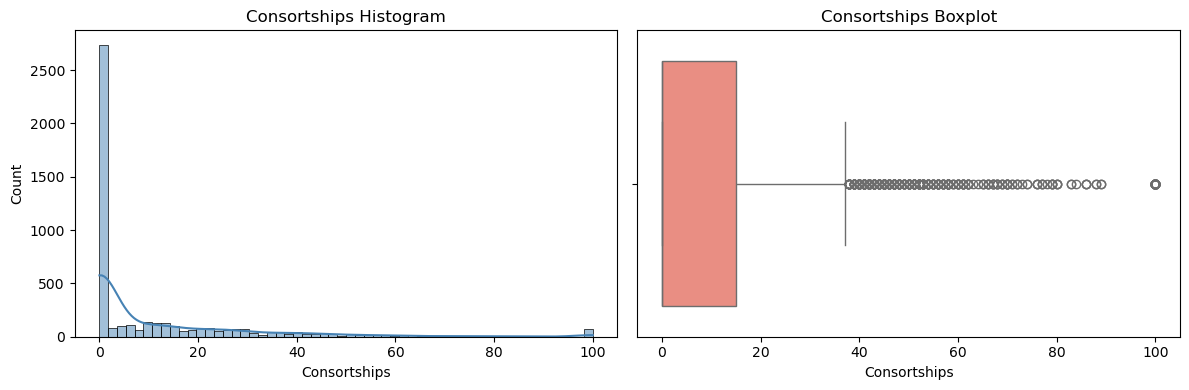

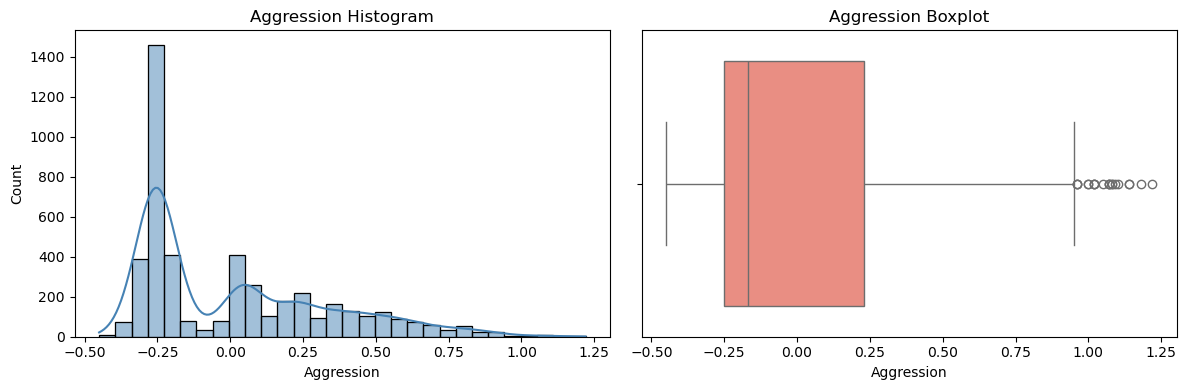

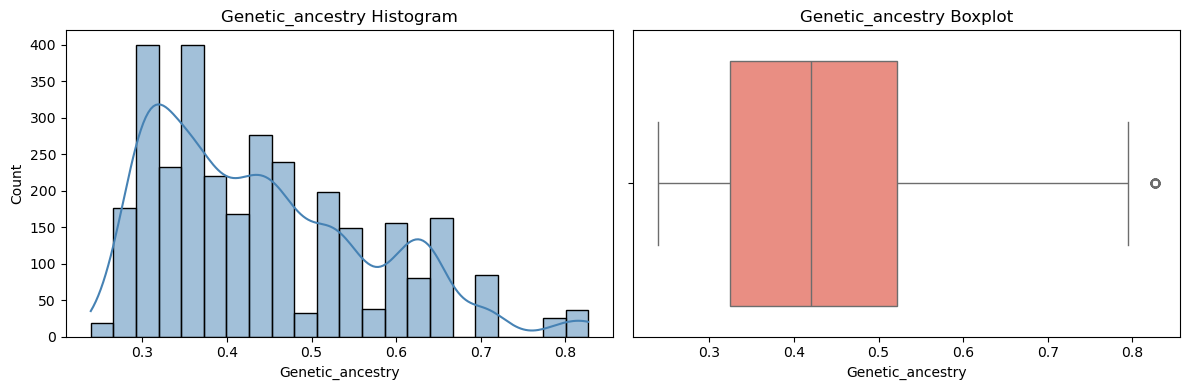

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=ax[0], color="steelblue")
    ax[0].set_title(f"{col} Histogram")

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1], color="salmon")
    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

## Boxplots of Hormone Levels by Social Rank

/var/folders/dz/4k59ykf93mjbpnsnw2w6vjh80000gn/T/ipykernel_65438/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


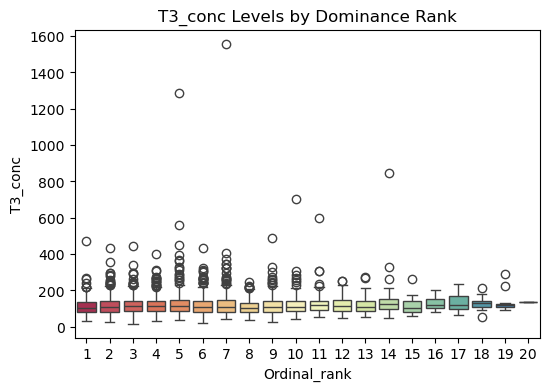

/var/folders/dz/4k59ykf93mjbpnsnw2w6vjh80000gn/T/ipykernel_65438/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


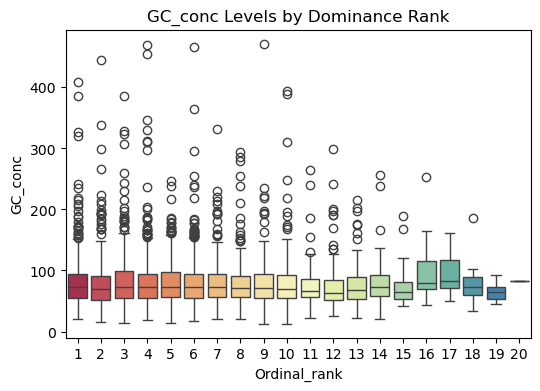

In [5]:
hormones = ["T3_conc", "GC_conc"]  

for h in hormones:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")
    plt.title(f"{h} Levels by Dominance Rank")
    plt.show()


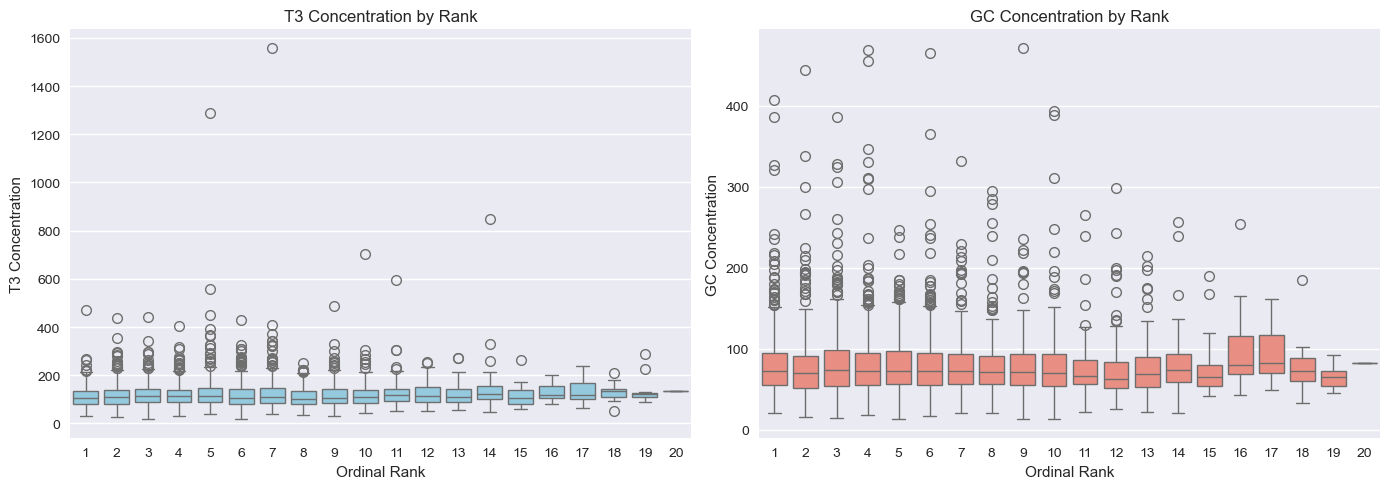

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x="Ordinal_rank",
    y="T3_conc",
    data=df,
    color="skyblue",
    ax=ax[0]
)
ax[0].set_title("T3 Concentration by Rank")
ax[0].set_xlabel("Ordinal Rank")
ax[0].set_ylabel("T3 Concentration")

sns.boxplot(
    x="Ordinal_rank",
    y="GC_conc",
    data=df,
    color="salmon",
    ax=ax[1]
)
ax[1].set_title("GC Concentration by Rank")
ax[1].set_xlabel("Ordinal Rank")
ax[1].set_ylabel("GC Concentration")

plt.tight_layout()
plt.show()


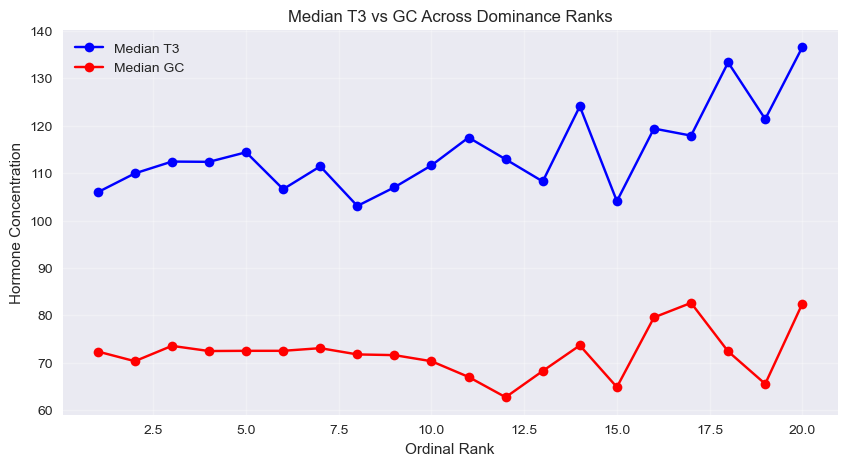

In [7]:
##Direct comparison of Median T3 and Median GC Across Ranks

rank_summary = df.groupby("Ordinal_rank")[["T3_conc", "GC_conc"]].median()

plt.figure(figsize=(10,5))
plt.plot(rank_summary.index, rank_summary["T3_conc"], marker="o", label="Median T3", color="blue")
plt.plot(rank_summary.index, rank_summary["GC_conc"], marker="o", label="Median GC", color="red")

plt.title("Median T3 vs GC Across Dominance Ranks")
plt.xlabel("Ordinal Rank")
plt.ylabel("Hormone Concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


I like this because it shows the different patterns of T3 and GC across ranks. 
- T3 line rises at certainn ranks likely because of more aggression, mate guarding, or competition for resources which increase metabolic rate.
- T3 peaks in the lower ranks
- GC line is mostly flat.
- Stress levels are not as varied across ranks compared to T3.

## Analysis

In [8]:
#using linear regression

from sklearn.linear_model import LinearRegression

X = df[['Ordinal_rank']]
y_T3 = df['T3_conc']
y_gc = df['GC_conc']

model_T3 = LinearRegression()
model_T3.fit(X, y_T3)

model_gc = LinearRegression()
model_gc.fit(X, y_gc)

#find coefficients
print("T3 slope:", model_T3.coef_[0])
print("T3 intercept:", model_T3.intercept_)
print()

print("Glucocorticoid slope:", model_gc.coef_[0])
print("Glucocorticoid intercept:", model_gc.intercept_)
print()

# R^2
print("T3 R^2:", model_T3.score(X, y_T3))
print("Glucocorticoid R^2:", model_gc.score(X, y_gc))

T3 slope: 0.6720219200829967
T3 intercept: 115.78987865525153

Glucocorticoid slope: -0.14484787664221863
Glucocorticoid intercept: 80.7585195394878

T3 R^2: 0.0018401524454575435
Glucocorticoid R^2: 0.0001679488509450655


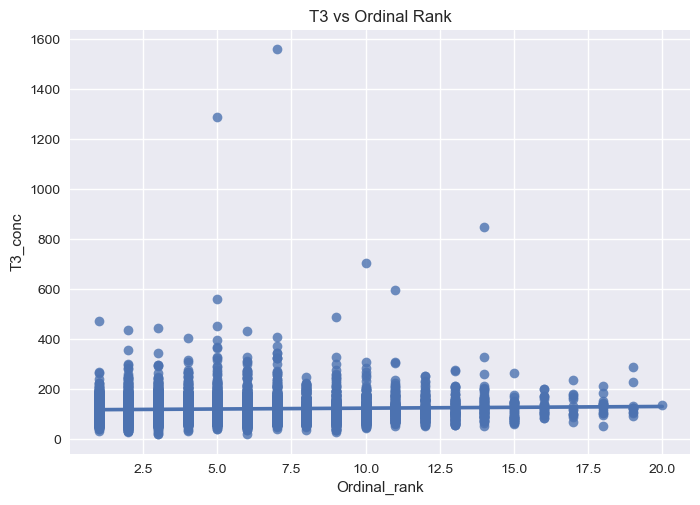

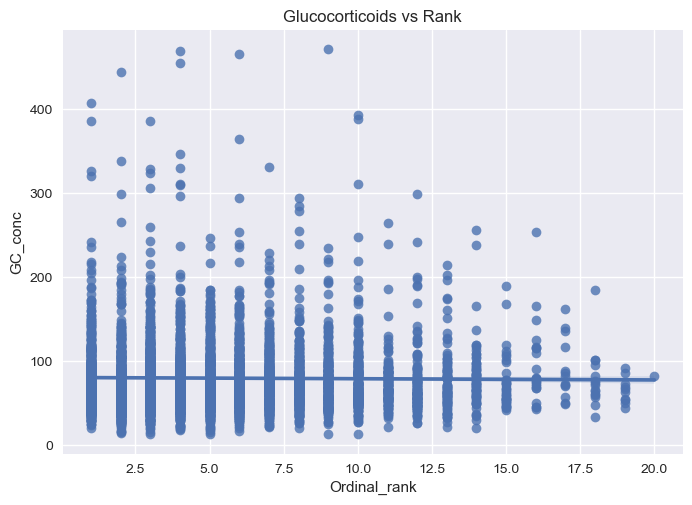

In [9]:
#visual
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x = 'Ordinal_rank', y = 'T3_conc', data = df)
plt.title("T3 vs Ordinal Rank")
plt.show()

sns.regplot(x = 'Ordinal_rank', y = 'GC_conc', data = df)
plt.title("Glucocorticoids vs Rank")
plt.show()

#### Both R^2's were very small, showing that T3 only explained 0.18% of the variation and GC only explained 0.016% of the variation. There is no strong evidence that rank meaningfully predicts stress levels in baboons.But with the slope, we do see higher levels of GC with higher ordinal ranks.

### Looking at other factors

In [11]:
from sklearn.linear_model import LinearRegression

# predictors
X = df[['Ordinal_rank', 'Age', 'Aggression', 'Consortships']]

# drop missing values
df_model = df.dropna(subset=['Ordinal_rank', 'Age', 'Aggression', 'Consortships', 'T3_conc', 'GC_conc'])

X = df_model[['Ordinal_rank', 'Age', 'Aggression', 'Consortships']]
y_T3 = df_model['T3_conc']
y_gc = df_model['GC_conc']

# models
model_T3 = LinearRegression()
model_T3.fit(X, y_T3)

model_gc = LinearRegression()
model_gc.fit(X, y_gc)

# results
print("T3 R^2:", model_T3.score(X, y_T3))
print("GC R^2:", model_gc.score(X, y_gc))

print("T3 coefficients:", model_T3.coef_)
print("GC coefficients:", model_gc.coef_)

T3 R^2: 0.003911748871165521
GC R^2: 0.005742776409123462
T3 coefficients: [ 0.85229135 -0.16032567 -4.26958312  0.14069487]
GC coefficients: [ 0.23265817 -0.01087696  1.58643239  0.16350535]


#### Even with multiple variables, the model explains less than 1% of the variation.
#### looking at the outputs, it looks like aggression is the strongest signal -> lower T3 and higher GC slope = more aggression, which is biologically meaningful

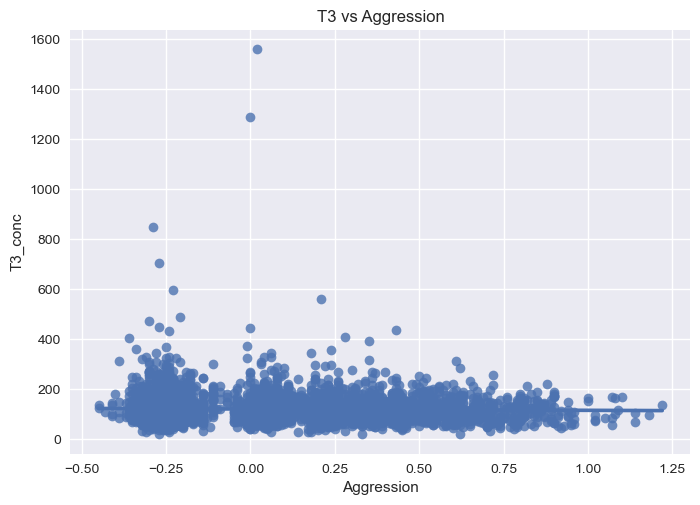

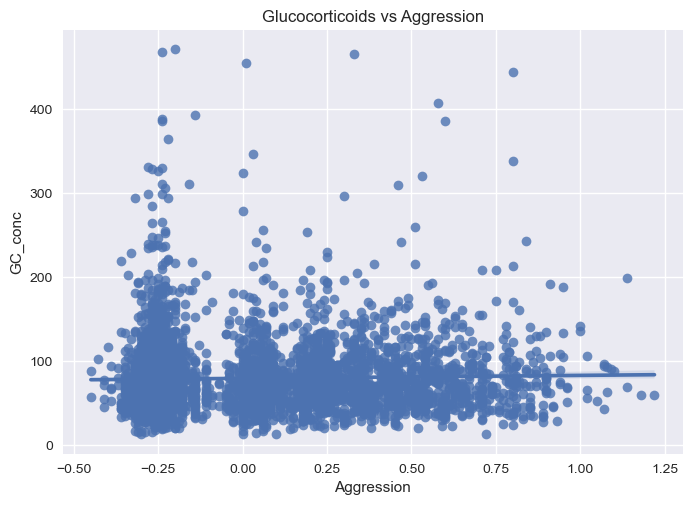

In [12]:
sns.regplot(x = 'Aggression', y = 'T3_conc', data = df)
plt.title("T3 vs Aggression")
plt.show()

sns.regplot(x = 'Aggression', y = 'GC_conc', data = df)
plt.title("Glucocorticoids vs Aggression")
plt.show()

#### with alpha vs non-alpha

In [14]:
# convert alpha status to 0/1
df_model['Alpha_binary'] = df_model['Alpha_status'].map({
    'alpha': 1,
    'non-alpha': 0
})

X = df_model[['Alpha_binary']]

# T3
model_T3_alpha = LinearRegression()
model_T3_alpha.fit(X, df_model['T3_conc'])

# GC
model_gc_alpha = LinearRegression()
model_gc_alpha.fit(X, df_model['GC_conc'])

# results
print("T3 R^2:", model_T3_alpha.score(X, df_model['T3_conc']))
print("GC R^2:", model_gc_alpha.score(X, df_model['GC_conc']))

print("T3 coefficient:", model_T3_alpha.coef_[0])
print("GC coefficient:", model_gc_alpha.coef_[0])

T3 R^2: 0.002589245713402688
GC R^2: 0.00011983832207662637
T3 coefficient: -9.145471835640736
GC coefficient: 1.4037327119199352


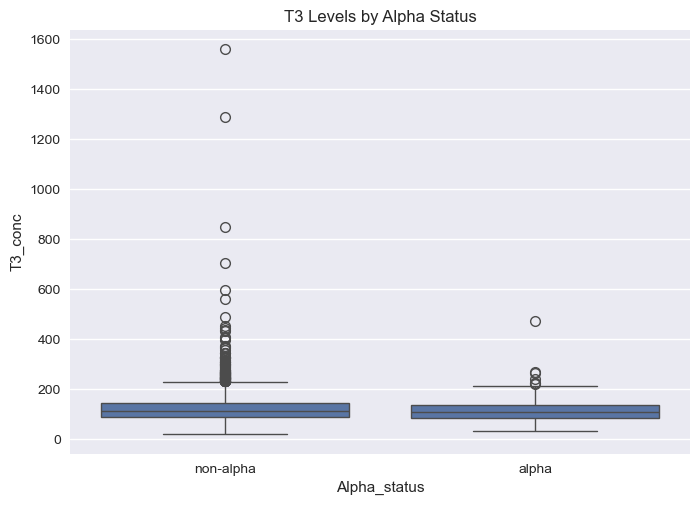

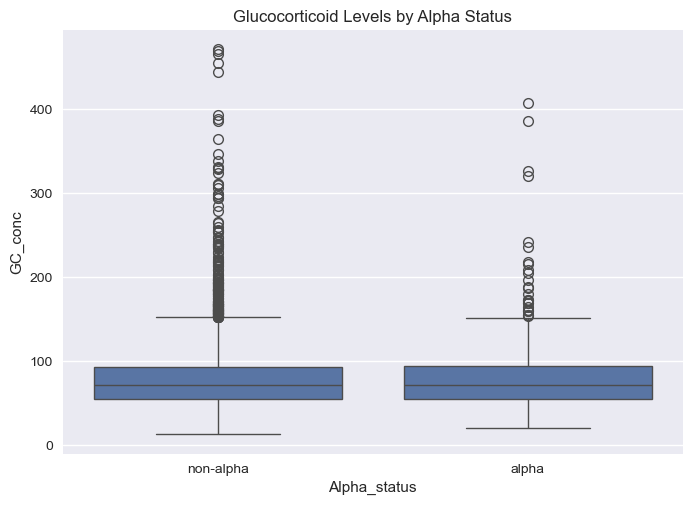

In [16]:

sns.boxplot(x='Alpha_status', y='T3_conc', data=df_model)
plt.title("T3 Levels by Alpha Status")
plt.show()

sns.boxplot(x='Alpha_status', y='GC_conc', data=df_model)
plt.title("Glucocorticoid Levels by Alpha Status")
plt.show()


#### looking at stability

In [ ]:
stable_df = df[df["Hierarchy_stability"] == "stable"]
unstable_df = df[df["Hierarchy_stability"] == "unstable"]

sns.boxplot(data=df, x="Alpha_status", y="GC_conc", hue="stability")
plt.title("GC by Alpha Status and Hierarchical Stability")
plt.show()


In [19]:
df.groupby(["Alpha_status", "Hierarchy_stability"])["GC_conc"].describe()

count       mean        std    min     25%  \
Alpha_status Hierarchy_stability                                                
alpha        stable                203.0  81.063547  42.536620  24.95  53.855   
             unstable              343.0  81.249475  41.915173  20.65  55.895   
non-alpha    stable               1605.0  77.003782  38.353721  13.11  52.760   
             unstable             2546.0  81.524611  42.455054  13.12  55.915   

                                     50%     75%     max  
Alpha_status Hierarchy_stability                          
alpha        stable               73.930  94.210  385.88  
             unstable             71.590  94.480  407.70  
non-alpha    stable               70.230  90.650  465.68  
             unstable             73.095  95.215  471.36

In [21]:
df.groupby(["Alpha_status", "Hierarchy_stability"])["T3_conc"].describe()

count        mean        std    min  \
Alpha_status Hierarchy_stability                                         
alpha        stable                203.0  115.650788  47.702575  32.96   
             unstable              343.0  109.052974  38.042394  37.90   
non-alpha    stable               1605.0  123.196636  60.592597  28.29   
             unstable             2546.0  119.047011  58.402265  17.84   

                                      25%     50%       75%      max  
Alpha_status Hierarchy_stability                                      
alpha        stable               85.6750  107.10  139.0250   470.91  
             unstable             80.7450  105.33  134.1200   266.67  
non-alpha    stable               87.5800  113.97  145.2100  1288.72  
             unstable             84.4775  109.09  141.1625  1557.82

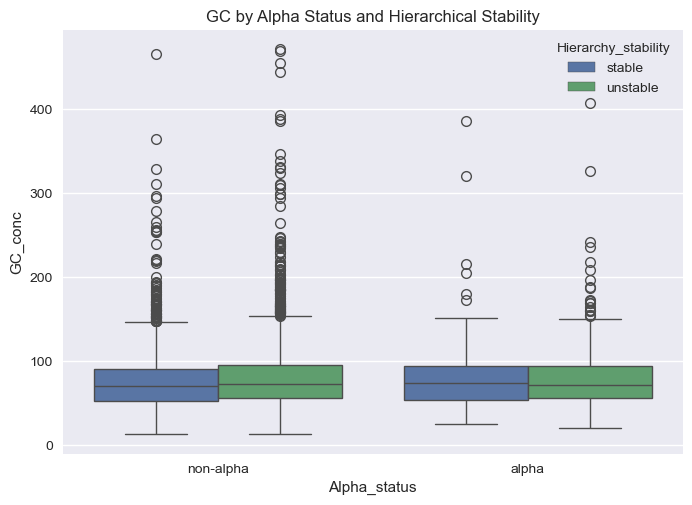

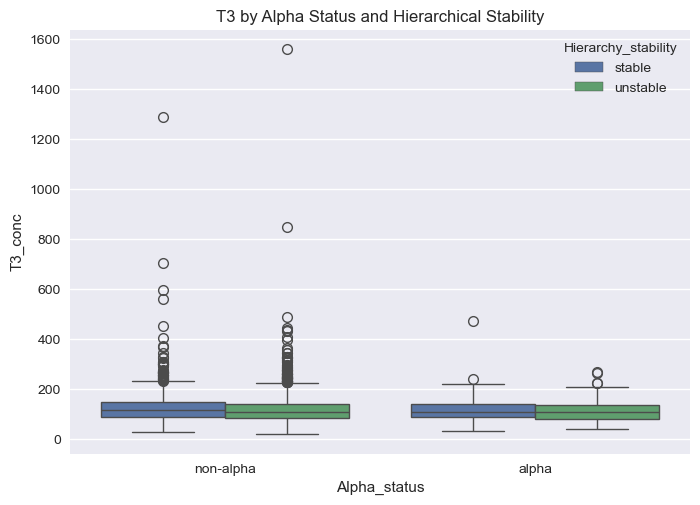

In [23]:
sns.boxplot(data=df, x="Alpha_status", y="GC_conc", hue="Hierarchy_stability")
plt.title("GC by Alpha Status and Hierarchical Stability")
plt.show()

sns.boxplot(data=df, x="Alpha_status", y="T3_conc", hue="Hierarchy_stability")
plt.title("T3 by Alpha Status and Hierarchical Stability")
plt.show()

In [24]:
df.groupby(["Alpha_status", "Hierarchy_stability"])["GC_conc"].var()


Alpha_status  Hierarchy_stability
alpha         stable                 1809.364075
              unstable               1756.881759
non-alpha     stable                 1471.007883
              unstable               1802.431605
Name: GC_conc, dtype: float64